# Exploratory Data Analysis and Introduction

### Objectives
1. Introduce the project, dataset, and analysis objectives.
2. Understand the overall characteristics and quality of the dataset through exploratory data analysis.
3. Explore relationships, patterns, and trends among the key variables.
4. Generate insights that will answer the project's analytical questions.

 ### Questions to Answer
1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?
4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

I'll be focusing on US Data Analyst roles, but you can adapt to any of the following:

## 1. Import Libraries

In [142]:
# there are all libraries I will need in this notebook.
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
# import numpy as np 
import ast


## 2. Load dataset 


In [143]:
df=pd.read_csv("../data/data_jobs.csv")
df.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."


## 3. Data Inspection 

In [144]:
df.shape # there is a 780,000+ rows and 17 columns table in the (csv file)

(785741, 17)

In [145]:
df.columns

# Observation:
# - Column names are stored as strings and follow snake_case naming convention.
# - Reviewing column names helps understand the available features and their purpose.

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='str')

In [146]:
#df.dtypes 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  str    
 1   job_title              785740 non-null  str    
 2   job_location           784696 non-null  str    
 3   job_via                785733 non-null  str    
 4   job_schedule_type      773074 non-null  str    
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  str    
 7   job_posted_date        785741 non-null  str    
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  str    
 11  salary_rate            33067 non-null   str    
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-null  str    

### Data Type Observations

- The `job_posted_date` column is stored as an object type. It should be converted to datetime for extracting year, month, and day information.
- The `job_skills` column contains skill lists stored as objects. It may need to be exploded later for individual skill analysis.
- Salary-related columns contain a large number of missing values.

In [147]:
df.sample(4)   #some random records 

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
325092,Senior Data Engineer,Senior Data Engineer,"London, UK",via LinkedIn,Full-time,False,United Kingdom,2023-05-15 17:54:12,False,False,United Kingdom,NaN,NaN,NaN,ClickJobs.io,"['sql', 'python', 'azure', 'databricks', 'pysp...","{'cloud': ['azure', 'databricks'], 'libraries'..."
329495,Senior Data Scientist,Advanced Analytics Analyst Sr,"San Juan, Puerto Rico",via Búsqueda De Empleo En Talent.com,Full-time,False,Puerto Rico,2023-06-29 00:24:25,False,False,Puerto Rico,NaN,NaN,NaN,Elevance Health,"['sas', 'sas', 'sql', 'sql server']","{'analyst_tools': ['sas'], 'databases': ['sql ..."
697091,Data Engineer,Data Engineer,"Ho Chi Minh City, Vietnam",via LinkedIn Vietnam,Full-time,False,Vietnam,2023-01-30 03:21:09,False,False,Vietnam,NaN,NaN,NaN,VNG Corporation,NaN,NaN
515196,Business Analyst,"Bank Risk Manager, Risk Strategy and Analytics",Hong Kong,via BeBee 香港,Full-time,False,Hong Kong,2023-09-20 11:28:17,False,False,Hong Kong,NaN,NaN,NaN,SUPER Corporate Consultancy Group,"['sas', 'sas', 'word']","{'analyst_tools': ['sas', 'word'], 'programmin..."


In [148]:
df.describe()

# Summary statistics for numerical columns.( yearly and hourly salary rate)
# Salary distributions are right-skewed, with a small number of high-paying jobs increasing the upper range.
# Potential outliers will be considered during salary analysis.

,salary_year_avg,salary_hour_avg
count,22003.000000,10662.000000
mean,123286.274072,47.016598
std,48312.449482,21.890738
min,15000.000000,8.000000
25%,90000.000000,27.500000
50%,115000.000000,45.980000
75%,150000.000000,61.159996
max,960000.000000,391.000000


In [149]:
df.isna().sum() 
# Checking missing values in each column.

# Observations:
# - Salary-related columns have the highest number of missing values because many job postings do not provide salary information.
# - job_skills and job_type_skills have missing values because some postings do not include required skills.
# - job_location, job_schedule_type, and company_name have a small number of missing values compared to the total dataset size.
# - These missing values should be evaluated before deciding whether to remove or handle them.

job_title_short               0
job_title                     1
job_location               1045
job_via                       8
job_schedule_type         12667
job_work_from_home            0
search_location               0
job_posted_date               0
job_no_degree_mention         0
job_health_insurance          0
job_country                  49
salary_rate              752674
salary_year_avg          763738
salary_hour_avg          775079
company_name                 18
job_skills               117037
job_type_skills          117037
dtype: int64

In [150]:
df.duplicated().sum() # there are 101 duplicated records. later in cleaning it can be dropped

np.int64(101)

In [151]:
df['job_health_insurance'].value_counts() # this is showing more jobs are without health insurance.

job_health_insurance
False    699244
True      86497
Name: count, dtype: int64

In [152]:
df['job_work_from_home'].value_counts() # this shows how many jobs are remote and onsite.

job_work_from_home
False    716189
True      69552
Name: count, dtype: int64

In [153]:
df['job_no_degree_mention'].value_counts() # this shows in how many jobs degree is mentioned and is not

job_no_degree_mention
False    544965
True     240776
Name: count, dtype: int64

In [154]:
df['salary_rate'].value_counts()

# Salary frequency distribution.
# Yearly salary is the most common, followed by hourly salary.
# Yearly salary will be used for analysis due to more available records.

salary_rate
year     22004
hour     10662
month      382
week        10
day          9
Name: count, dtype: int64

In [155]:
df['job_schedule_type'].value_counts().head()
# full time domination after contractor.

job_schedule_type
Full-time                  701727
Contractor                  34793
Internship                   8742
Part-time                    7881
Full-time and Part-time      6287
Name: count, dtype: int64

In [156]:
df['job_schedule_type'].count()    # how many non- null values are ther.

np.int64(773074)

In [157]:
df['job_title_short'].unique()    # unique data roles

<StringArray>
[     'Senior Data Engineer',              'Data Analyst',
             'Data Engineer',          'Business Analyst',
            'Data Scientist', 'Machine Learning Engineer',
       'Senior Data Analyst',            'Cloud Engineer',
     'Senior Data Scientist',         'Software Engineer']
Length: 10, dtype: str

## 4. Data Cleaning

In [158]:
# Remove duplicate records
df_cleaned = df.drop_duplicates().copy()

print(f"Rows before removing duplicates: {len(df)}")
print(f"Rows after removing duplicates: {len(df_cleaned)}")
print(f"Duplicate rows removed: {len(df) - len(df_cleaned)}")

Rows before removing duplicates: 785741
Rows after removing duplicates: 785640
Duplicate rows removed: 101


In [159]:
df_cleaned['job_posted_date']=pd.to_datetime(df_cleaned['job_posted_date'])

In [160]:
# #job skill should be list object 
df_cleaned['job_skills']=df_cleaned['job_skills'].apply(lambda job_skill: ast.literal_eval(job_skill) if pd.notna(job_skill) else job_skill)

In [161]:
# #job_type_skills should be dictionary obj
df_cleaned['job_type_skills']=df_cleaned['job_type_skills'].apply(lambda job_type: ast.literal_eval(job_type) if pd.notna(job_type) else job_type)

In [162]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 785640 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785640 non-null  str           
 1   job_title              785639 non-null  str           
 2   job_location           784595 non-null  str           
 3   job_via                785632 non-null  str           
 4   job_schedule_type      772975 non-null  str           
 5   job_work_from_home     785640 non-null  bool          
 6   search_location        785640 non-null  str           
 7   job_posted_date        785640 non-null  datetime64[us]
 8   job_no_degree_mention  785640 non-null  bool          
 9   job_health_insurance   785640 non-null  bool          
 10  job_country            785591 non-null  str           
 11  salary_rate            33066 non-null   str           
 12  salary_year_avg        22002 non-null   float64       
 13  

In [163]:
df.isna().sum()


#Most missing values are expected because not every job posting provides 
# salary, skills, company information, or schedule details. 
# These missing values will be preserved and handled only when required for a specific analysis.

job_title_short               0
job_title                     1
job_location               1045
job_via                       8
job_schedule_type         12667
job_work_from_home            0
search_location               0
job_posted_date               0
job_no_degree_mention         0
job_health_insurance          0
job_country                  49
salary_rate              752674
salary_year_avg          763738
salary_hour_avg          775079
company_name                 18
job_skills               117037
job_type_skills          117037
dtype: int64

## 5. EDA
#### General exploration for the dataset 

In [164]:
df_EDA=df_cleaned.copy()


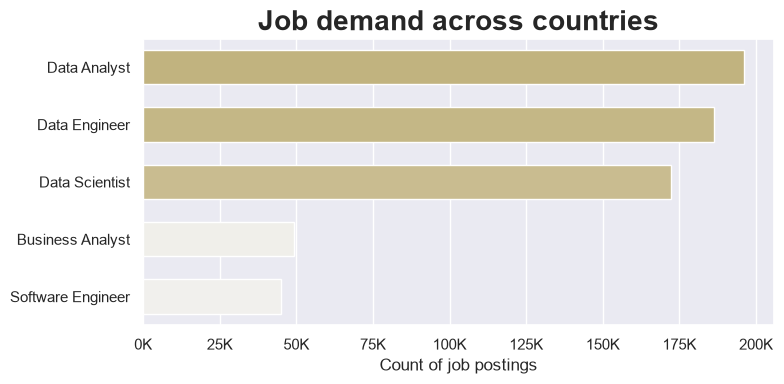

In [165]:
# top 5 jobs, demanded in 2023 across all countries 
jobs_demand=df_EDA['job_title_short'].value_counts().head().to_frame().reset_index()



sns.set_theme(style='darkgrid')
plt.figure(figsize=(8,4))
sns.barplot(
    data=jobs_demand,
    x="count",
    y="job_title_short"
    ,width=0.6,
    hue='count',
    palette='light:y'
)
plt.title("Job demand across countries", weight="bold", fontsize=20)
plt.xlabel("Count of job postings")
plt.ylabel("")
plt.legend().remove()
ax1=plt.gca()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.tight_layout()
plt.show()

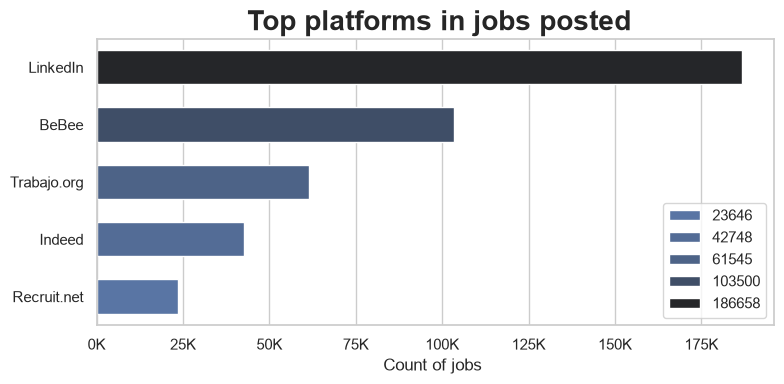

In [166]:
# top 5 platforms posted jobs

top_platforms= df_EDA["job_via"].str.replace("via ", "").value_counts().head().reset_index()

sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,4))
sns.barplot(
    data=top_platforms,
    x="count",
    y="job_via"
    ,width=0.6,
    hue='count',
    palette='dark:b_r'
)
plt.title(" Top platforms in jobs posted", weight="bold", fontsize=20)
plt.xlabel("Count of jobs ")
plt.ylabel("")
plt.legend().remove()
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.legend()
plt.tight_layout()
plt.show()

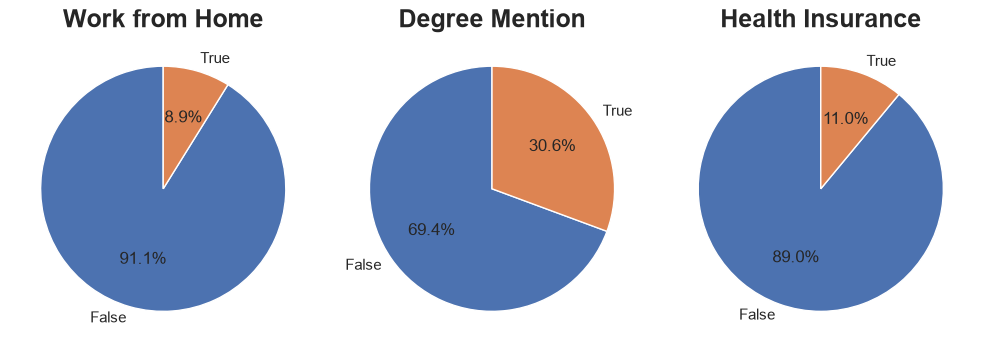

In [167]:
# categorical features analysis including remote & onsite jobs, job degree mentioned or not, and health insurance provided jobs. 
# job apporutnities 
fig, axis=plt.subplots(1,3,figsize=(10,7))


dict_cols={
    'job_work_from_home':'Work from Home',
    'job_no_degree_mention': 'Degree Mention',
    'job_health_insurance':'Health Insurance'
}
for index, (job, title) in enumerate(dict_cols.items()):
    axis[index].pie(df_EDA[job].value_counts(),labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    axis[index].set_title(title, weight="bold", fontsize=18)

plt.tight_layout()
plt.show()

In [168]:
# most common schedule types jobs
schedule_df = df_EDA[["job_schedule_type"]].dropna().copy()

#replacing names Pekerjaan tetap and Kontraktor
schedule_df["job_schedule_type"] = schedule_df["job_schedule_type"].replace({
    "Pekerjaan tetap": "Full-time",
    "Kontraktor": "Contractor"
})

#
schedule_df["job_schedule_type"] = (
    schedule_df["job_schedule_type"]
    .str.split(r",?\s+and\s+|,\s*")
)

#explode them in different schedule type names
schedule_df=schedule_df.explode('job_schedule_type').value_counts().reset_index()

#showing dataframe which is built in this process
schedule_df

# so the most important types are top 4 
schedule_df=schedule_df.head(4)

#for better quality of analysis there are what I did:
# "Pekerjaan tetap" and "Kontraktor", They are Indonesian/Malay words so they need to be replaced m 
# there was combinations of schedule type names; which regex is used to solve the problem and explode for clear frequency counts 


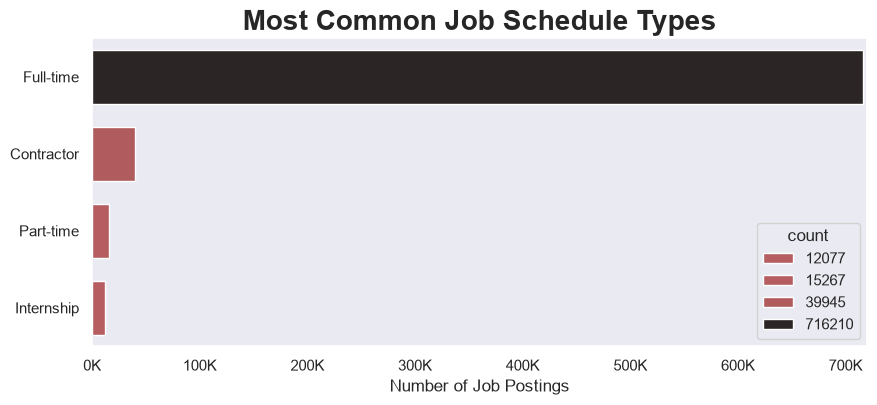

In [169]:

sns.set_theme(style='dark')

plt.figure(figsize=(10,4))

sns.barplot(
    data=schedule_df,
    x="count",
    y="job_schedule_type",
    hue="count",
    palette="dark:r_r",
    width=0.7
)

plt.title("Most Common Job Schedule Types", weight="bold", fontsize=20)
plt.xlabel("Number of Job Postings")
plt.ylabel("")
plt.xlim(0,720000)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.show()

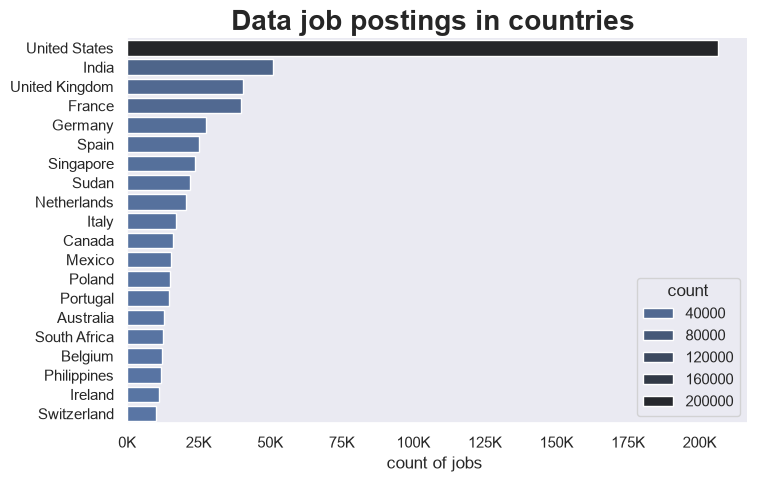

In [170]:
# number of job posted in all countries
country_df=df_EDA['job_country'].value_counts().head(20).to_frame()

sns.set_theme(style='dark')
plt.figure(figsize=(8,5))


sns.barplot(data=country_df, x='count', y='job_country', hue='count', palette='dark:b_r')
plt.title("Data job postings in countries ", weight="bold", fontsize=20)
plt.ylabel("")
plt.xlabel("count of jobs ")
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
sns.despine()
plt.show()


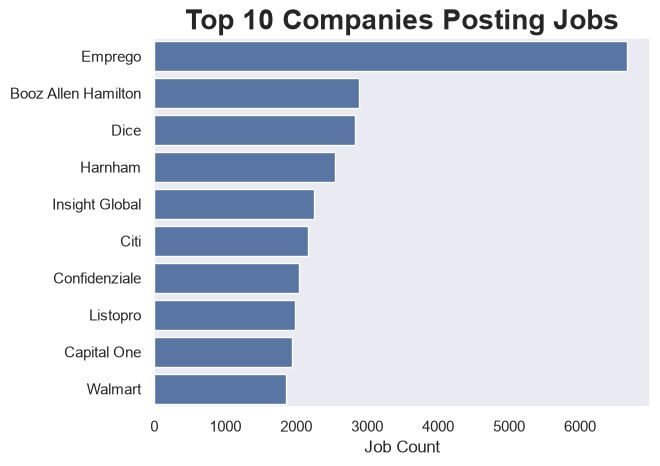

In [171]:
# Top 10 company names
top_companies = df_EDA["company_name"].value_counts().head(10).index

sns.countplot(
    data=df_EDA[df_EDA["company_name"].isin(top_companies)],
    y="company_name",
    order=top_companies
)

plt.title("Top 10 Companies Posting Jobs", weight="bold", fontsize=20)
plt.xlabel("Job Count")
plt.ylabel("")
plt.show()

### EDA for UK 

In [ ]:
skill_type_dict=df_EDA["job_type_skills"].dropna()
skill_type_dict

,job_type_skills
1,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,"{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,"{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,"{'cloud': ['gcp'], 'programming': ['python', '..."
...,...
785736,"{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,"{'analyst_tools': ['powerpoint', 'excel']}"
785739,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


#### UK data scientist role analysis

## 6. Key Findings